In [466]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [467]:
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)

20.0

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

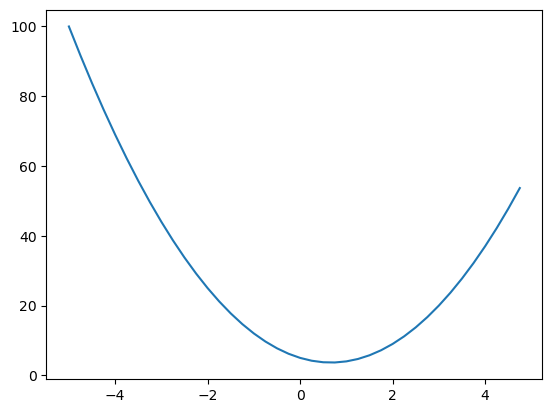

In [468]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
xs

In [469]:
# Derivative Numerical Approximation
h = 0.001
x = 2/3
(f(x + h) - f(x)) / h

0.0029999999995311555

In [470]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [537]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h  # where f = ab + c, df/da = b = -3
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [538]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [473]:
# Visualize DAG
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v) 
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

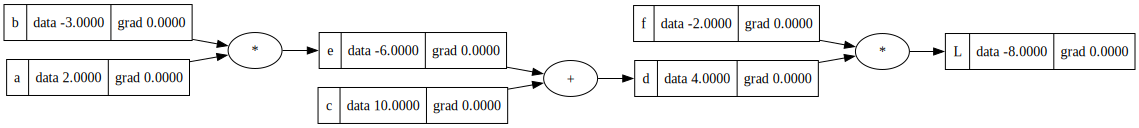

In [474]:
draw_dot(L)

# Manual Backprop 
## Layer 1

L = d * f  # def
dL/dd = ? = f

derivative of f(x) wrt x:
df/dx = lim as h->0 of (f(x+h) - f(x))/h

d.grad = dL/dd
= ((d+h)*f - d*f)/h
= (h * f)/h
dL/dd = f = -2.0

Similarly:
f.grad = dL/df 
dL/df = d = 4.0

## Layer 2
BUT, what about dL/dc and dL/de?

First consider the chain rule: *d/dx( f(g(x)) ) = f'(g(x)) * g'(x) = df/dg * dg/dx*
c.grad = dL/dc
= (dd/dc) * (dL/dd)

Find the "local derivative" one step previously:
dd/dc = ?
d = c + e -> dd/dc = 1.0
(f(c+h) - f(c))/h  # Check
= ((c + h + e) - (c + e))/h
= h/h = 1.0

Then, this "local derivative" can then be used in the chain rule:
dL/dc = (dd/dc) * (dL/dd)  # think of it as when c nudges d, the d nudges L, we can just multiply those together to get the total effect
dL/dc = 1.0 * -2.0 = -2.0

...
And we can do the same thing for dL/de
e.grad = dL/de
= (dd/de) * (dL/dd)  # where dd/de = 1.0
dL/de = 1.0 * -2.0 = -2.0

## Layer 3
Then we use the chain rule again: 
L = d * f = (e + c) * f = (((a * b) + c) * f)
d = e + c
e = a * b
dL/da = (de/da) * (dL/de) = (de/da) * (dd/de) * (dL/dd)
= b * -2.0
dL/da = 6.0

dL/db = (de/db) * (dL/de)
= a * -2.0
dL/db = -4.0

## Notice:
Backpropogation is multiplying these chains.

So long as we know the local derivative at each operation, we can do backpropogation.
- d/dx (a * x) = a
- d/dx (x + b) = 1
- d/dx (e^x) = e^x

-8.0


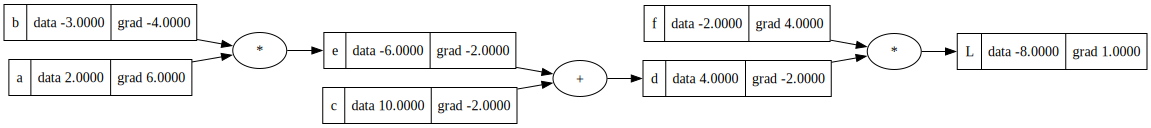

In [475]:
# Gradients computed manually above:
L.grad = 1
d.grad = -2
f.grad = 4
c.grad = -2
e.grad = -2
a.grad = 6
b.grad = -4

print(L.data)
draw_dot(L)

-7.286496


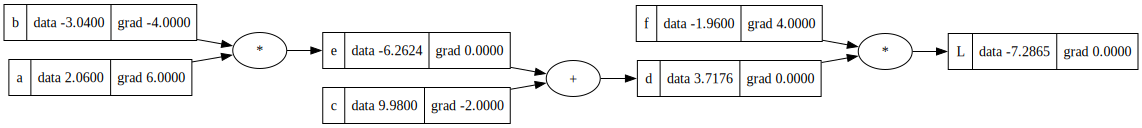

In [476]:
# Gradient ascent
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

# Compute new forward path Value
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
L = d * f; L.label = 'L'
print(L.data)

draw_dot(L)

In [477]:
def ex1():
    h = 0.001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 , label='a')  # add h somewhere here
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

ex1()

-3.9999999999995595


## Neuron
Weighted sum of inputs, plus a bias, passed through an activation function.

Below, we have a neuron with 2 inputs, a bias, and the tanh activation function.


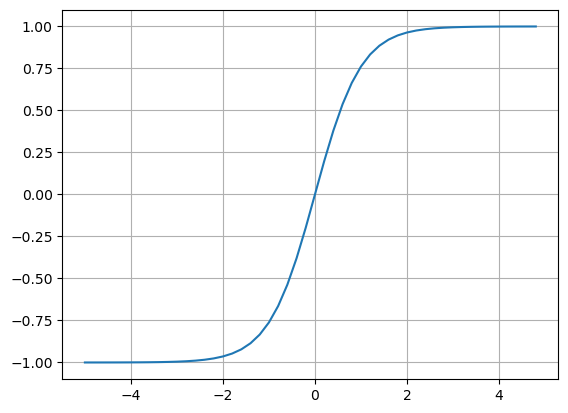

In [478]:
# Activation Function: tanh requires exponentiation
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [ ]:
### Define a Neuron
# Inputs: x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights: w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# Activation Function
o = n.tanh(); o.label = 'o'

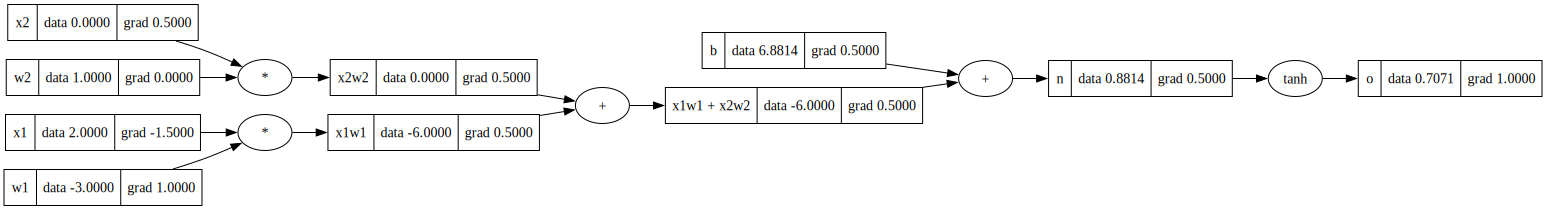

In [510]:
draw_dot(o)

In [503]:
### Manual Backprop for above
o.grad = 1.0  # by definition, d/dn(n) = 1
n.grad = 0.5  # from tanh
# Addition: derivative wrt. each term is 1 | (x1w1+x2w2) + b
b.grad = 0.5  # do/db = do/dn * dn/db = 0.5 * 1 = 0.5
x1w1x2w2.grad = 0.5  # same as b.grad
# Addition: dervivative wrt. each term is 1 | x1w1 + x2w2
x1w1.grad = 0.5  # d(x1w1)/do = d(x1w1+x2w2)/d(x1w1) * do/d(x1w1+x2w2) = 1 * 0.5
x2w2.grad = 0.5  # same as above
# Multiplication: d/dx (ax) = a, d/da (ax) = x
x1.grad = w1.data * x1w1.grad   # w1 * do/d(x1w1) = -1.5
w1.grad = x1.data * x1w1.grad   # x1 * do/d(x1w1) = 1.0
x2.grad = w2.data * x2w2.grad   # w2 * do/d(x1w1) = 0.5
w2.grad = x2.data * x2w2.grad   # x2 * do/d(x1w1) = 0

In [ ]:
### Automatic Backprop for above by calling _backward functions
o.grad = 1.0  # base case
o._backward()
n._backward()
b._backward()  # None
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()


In [483]:
# o = tanh(n)
# n.grad = do/dn = d/dn (tanh(n)) = 1 - [tanh(n)]^2
1 - o.data**2

0.4999999999999999

## Topological sort for Automatic Backprop
Here we use DFS with descending order of finish times.

We call _backwards on nodes in reverse topological order, since we want to start at the end propogating back.

This is then implemented inside the Value object as the backward(self) function.

In [ ]:
# Equivalent to Value.backward(): building topological graph
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

for node in reversed(topo):
    node._backward()

In [509]:
# Now is implemented in Value.backward()
o.backward()

## A Bug:
Whenever we use a variable multiple times, earlier calculations are lost.

Solution: *Accumulate* (Add, not set) gradients in multivariate case.

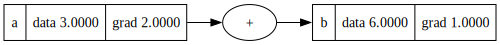

In [539]:
a = Value(3.0, label='a')
b = a + a; b.label = 'b'
b.backward()
draw_dot(b)

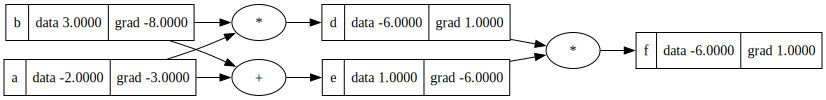

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)
